In [11]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
from utils.logger import get_logger
_logs = get_logger(__name__)

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [12]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import os
from glob import glob

In [13]:
ft_dir = os.getenv("FEATURES_DATA")
ft_glob = glob(os.path.join(ft_dir, '**/*.parquet'), 
               recursive = True)
df = dd.read_parquet(ft_glob).compute().reset_index()

# Sampling in Python

+ There are different packages that allow sampling.
+ A practical approach is to use pandas/Dask sampling methods.

## Random Sampling

+ Sample n rows from a dataframe with [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).

```
DataFrame.sample(
    n=None, frac=None, replace=False, weights=None, 
    random_state=None, axis=None, ignore_index=False
    )
```

In [14]:
df.sample(n = 5)

,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1
330497,VOLT,2010-03-24,10.620,10.750,10.470,10.5300,10.530000,35700.0,VOLT.csv,2010,10.6700
190779,MOS,1997-11-13,33.625,34.375,33.625,33.9375,25.865164,99500.0,MOS.csv,1997,33.5000
58794,CBB,1998-04-30,185.000,191.250,185.000,191.2500,76.122482,148100.0,CBB.csv,1998,184.6875
198484,NIM,2018-08-15,9.710,9.740,9.710,9.7400,9.264604,9000.0,NIM.csv,2018,9.6800
200173,NIM,1997-10-10,11.125,11.250,11.125,11.1250,4.207986,20200.0,NIM.csv,1997,11.3125


In [15]:
import random
random.seed(42)
sample_tickers = random.sample(df['ticker'].unique().tolist(), 30)
df = df[df['ticker'].isin(sample_tickers)]
simple_sample_dt = df.sample(frac = 0.1)
simple_sample_dt.shape, df.shape

((10732, 11), (107315, 11))

Look at the distribution of tickers.

<Axes: xlabel='ticker'>

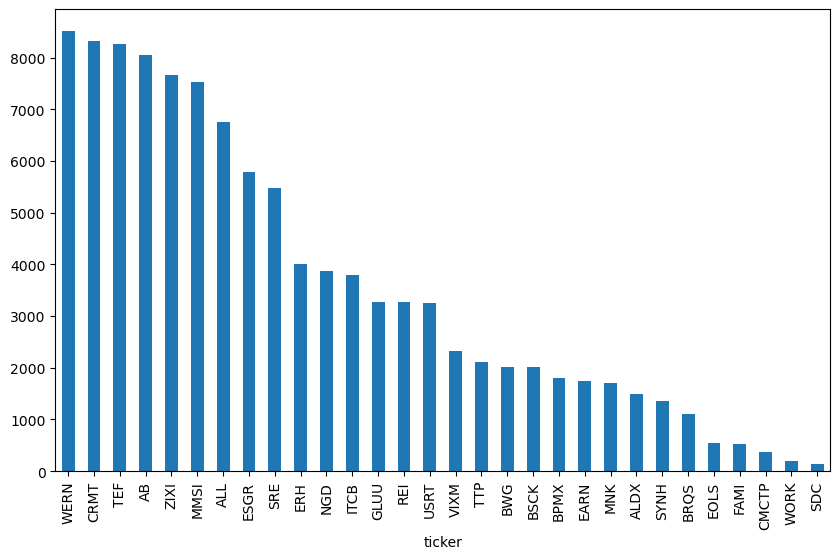

In [16]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

df['ticker'].value_counts().plot(kind='bar')

<Axes: xlabel='ticker'>

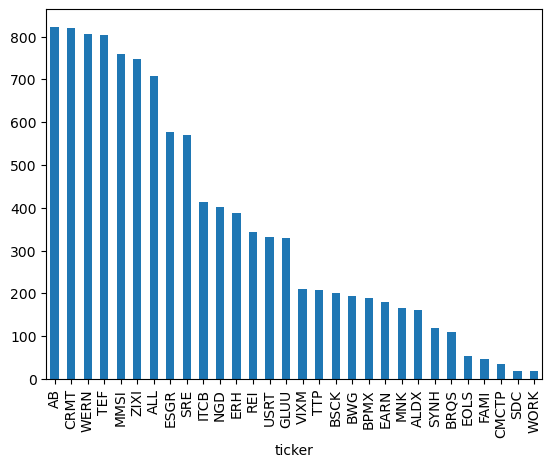

In [17]:
simple_sample_dt['ticker'].value_counts().plot(kind='bar')

## Stratified Sampling

+ Use `groupby()` and `.sample()` for stratified sampling.

<Axes: xlabel='ticker'>

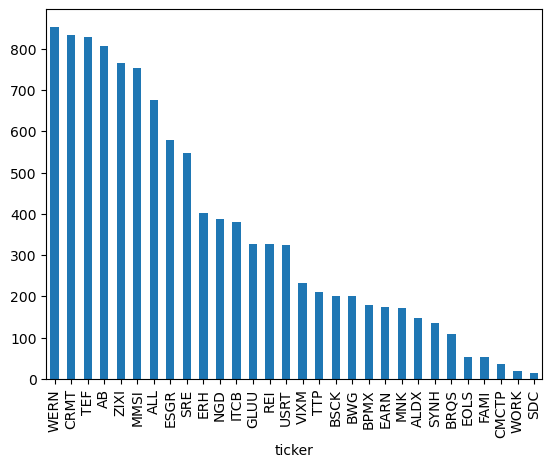

In [18]:
strat_sample_dt = df.groupby(['ticker']).sample(frac = 0.1)
strat_sample_dt['ticker'].value_counts().plot(kind='bar')

# Sampling in Dask

+ Stratified sampling in `dask` can be achieved with `groupby().apply()` and a lambda function.

C:\Users\Saad Khan\AppData\Local\Temp\ipykernel_13668\1783207470.py:4: UserWarning: `meta` is not specified, inferred from partial data.
Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result

  .apply(lambda x: x.sample(frac = 0.1))


<Axes: xlabel='ticker'>

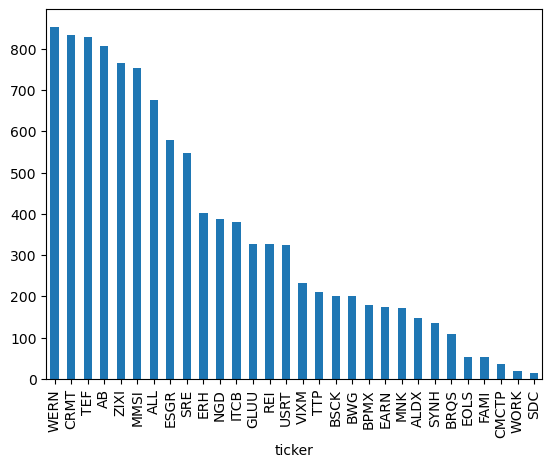

In [19]:
dd_dt = dd.read_parquet(ft_glob)
strat_sample_dd = (dd_dt
                      .groupby('ticker', group_keys=False)
                      .apply(lambda x: x.sample(frac = 0.1))
                      .compute()
                      .reset_index())
strat_sample_dd[strat_sample_dd['ticker'].isin(sample_tickers)]['ticker'].value_counts().plot(kind='bar')